# Лабораторная работа 8. 
## Кластеризация методом k-means

Сегодня мы поработаем датасетом о винах из пакете sklearn. Данный датасет обычно используют для классификации, но мы не будем загружать данные об истинных метках класса (о производителях вина), а с помощью методов кластеризации посмотрим, образуют ли эти вина какие-то группы по своему химическому составу. 

Для анализа будем использовать 2 наиболее популярных метода кластеризации: метод k средних и метод иерархической агломеративной кластеризации.

**Обзор доступных данных**

В выборке 178 наблюдений и 13 переменных. Целевой переменной является производитель вина. 



| Имя столбца          | Значение                             |
|:-----------------   :|:------------------------------------:|
| alcohol              | Алкоголь                             |
| malic_acid           | Яблочная кислота                     |
| ash                  | Пепел                                |
| alcalinity_of_ash    | Щелочность золы                      |
| magnesium            | Магний                               |
| total_phenols        | Общие фенолы                         |
| flavanoids           | Флаваноиды                           |
| nonflavanoid_phenols | Нефлаваноидные фенолы                |
| proanthocyanins      | Проантоцианы                         |
| color_intensity      | Интенсивность цвета                  |
| hue                  | Оттенок                              |
| od280/od315          | OD280 / OD315 разбавленных вин       |
| proline              | Пролин                               |

### Загрузим библиотеки

In [3]:
from sklearn.datasets import load_wine #датасет содержится в библиотеке scikit-learn
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

In [4]:
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.preprocessing import StandardScaler #метод z-нормализации переменных 
from sklearn.cluster import KMeans # реализация метода k средних в sklearn
from sklearn.metrics import silhouette_score, classification_report

### Загрузим данные

In [5]:
data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names) # в датасет df запишем только значения предикторов. Значения откликов мы отбрасываем
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


### 📌📌📌 Задание 1. Предварительный анализ данных

1. Выясните, есть ли в датасете  пропуски и какого типа предикторы
2. Построив для каждой переменной диаграммы размаха (Boxplots), выясните, имеются ли выбросы по значениям переменных

Инфо:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtyp

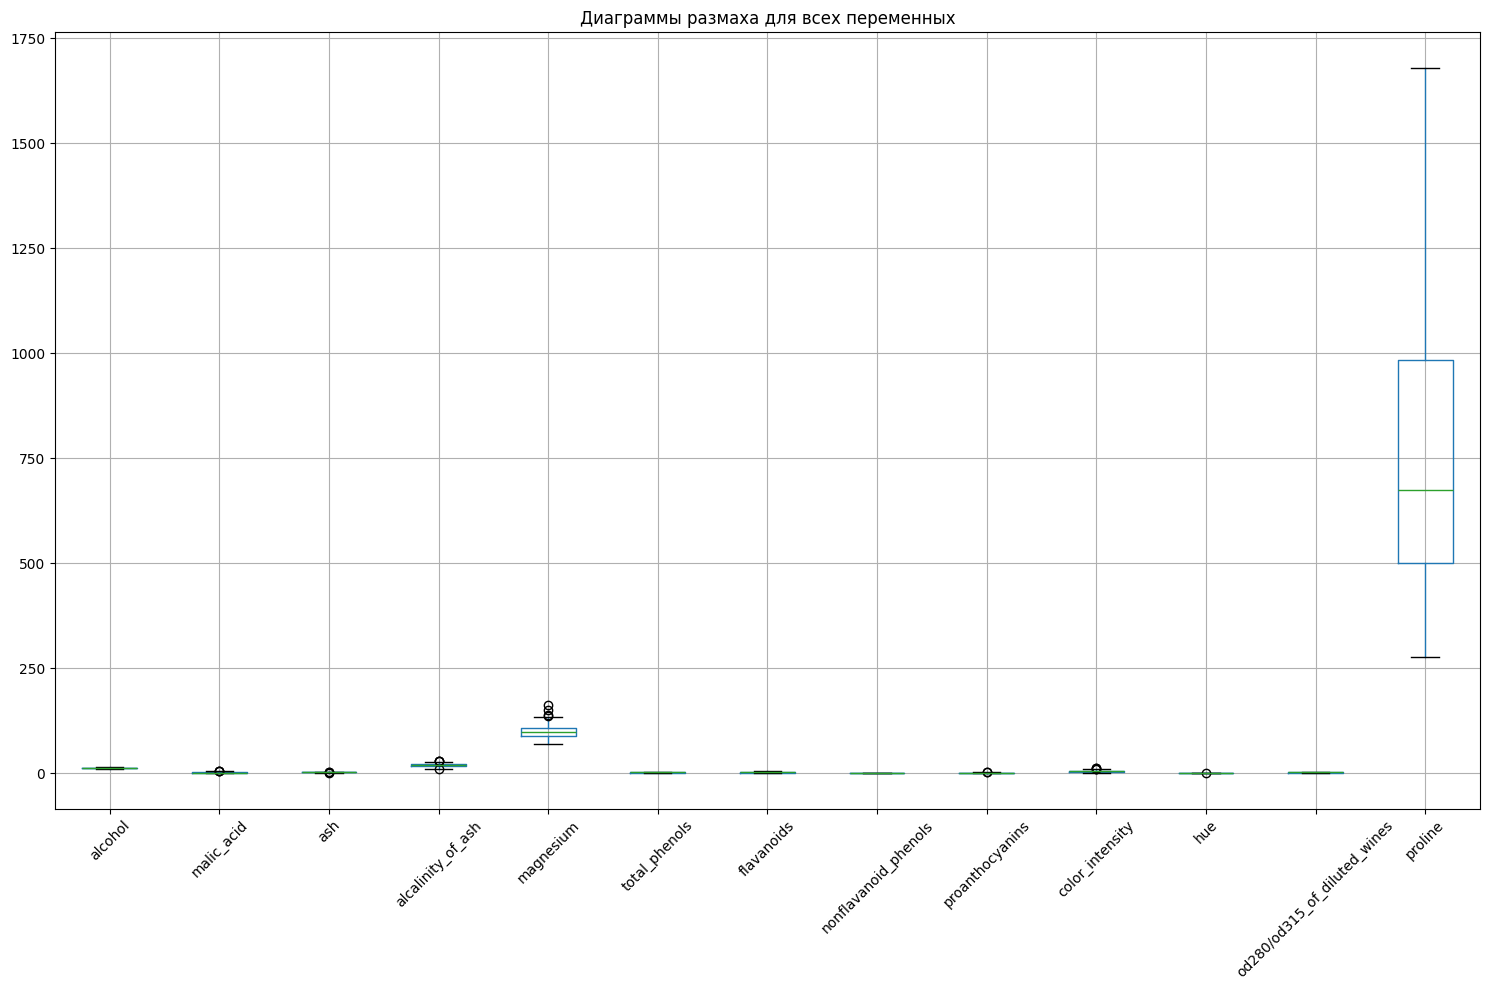

In [6]:
print("Инфо:")
print(df.info())
print("\nПропуски:")
print(df.isnull().sum())

plt.figure(figsize=(15, 10))
df.boxplot()
plt.title('Диаграммы размаха для всех переменных')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Проведем стандартизацию
Переменные датасета могут иметь разный масштаб (например, в нашем датасете переменная `magnesium` принимает значения  на \[70,162\], а переменная `malic_acid` - на  \[0.74-5.8\]). 

Так как метод k-means в качестве меры близости использует функцию расстояния, то переменные с большим масштабом будут вносить больший вклад в результаты кластеризации. Если переменные одинаково важны для решения задачи, то небходимо привести их к одному масштабу.

Существует несколько способов стандартиации (нормализации переменных). Изучите информацию о них по ссылкам:
- [z-стандартизация](https://www.helenkapatsa.ru/standartizatsiia/)
- [минимакс-стандартизация](https://www.helenkapatsa.ru/normalizatsiia/)

В нашей задаче будем использовать z-стандартизацию, которая реализована  в пакете `sklearn.preprocessing` с помощью функции `StandardScaler()`

In [7]:
scaler = StandardScaler()
dff = scaler.fit_transform(df) # обучение и одновременное применение стандартизатора к данным df
dff = pd.DataFrame(dff, columns=df.columns)# датасет из стандартизованных переменных
dff.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


### Определим, имеется ли в данных тенденция к кластеризации (с помощью статистики Хопкинса)
В Python на данный момент нет встроенного метода вычисления статистики Хопкинса, поэтому напишем пользовательную функцию.

In [8]:
# X - выборка, для которой вычисляется статистика Хопкинса
# knn - число  ближайших соседей для вычисления статистики
def hopkins(X,knn):
    
    from sklearn.neighbors import NearestNeighbors
    from random import sample
    from numpy.random import uniform
    import numpy as np
    from math import isnan
    
    d = X.shape[1]
    #d = len(vars) # columns
    n = len(X) # rows
    m = int(0.1 * n) 
    nbrs = NearestNeighbors(n_neighbors=knn).fit(X.values)
 
    rand_X = sample(range(0, n, 1), m)# генерируется псевдонабор данных, имеющих равномерное распределение
 
    ujd = []
    wjd = []
    for j in range(0, m):
        u_dist, _ = nbrs.kneighbors(uniform(np.amin(X,axis=0),np.amax(X,axis=0),d).reshape(1, -1), 2, return_distance=True)
        ujd.append(u_dist[0][1])
        w_dist, _ = nbrs.kneighbors(X.iloc[rand_X[j]].values.reshape(1, -1), 2, return_distance=True)
        wjd.append(w_dist[0][1])
 
    H = sum(ujd) / (sum(ujd) + sum(wjd))
    if isnan(H):
        print(ujd, wjd)
        H = 0
 
    return H

### 📌📌📌 Задание 2. Вычисление статистики Хопкинса и анализ результатов
**Варианты 1-3**:

Вычислите статистику Хопкинса для датасета `dff`, взяв в число ближайших соседей, равным:
- **Вариант 1**: 3
- **Вариант 2**: 4
- **Вариант 3**: 5

Сделайте вывод о наличии/отсутствии тенденции к кластеризации.

**Варианты 4**:
Как видно из синтаксиса функции `hopkins(X,knn)`, значение статистики будет зависить от псевдонабора данных, который генерируется в процессе вычисления статистики. 

Будет правильнее вычислить статитику Хопкинса несколько раз (т.е. для нескольких случайных псевдонаборов), а потом принять решение о тенденции о кластеризации, взяв среднее значение статистики. 

Реализуйте это. Самостоятельно примите решение о количестве вычислений статистике и числе ближайших соседей.


In [9]:
### Ваш код
hopkins_values = []
for i in range(10):
    h_val = hopkins(dff, knn=5)  
    hopkins_values.append(h_val)

mean_hopkins = np.mean(hopkins_values)
print(f"Среднее значение статистики Хопкинса: {mean_hopkins:.3f}")

if mean_hopkins > 0.75:
    print("Сильная тенденция к кластеризации")
elif mean_hopkins > 0.5:
    print("Умеренная тенденция к кластеризации")
else:
    print("Нет тенденции к кластеризации")

Среднее значение статистики Хопкинса: 0.721
Умеренная тенденция к кластеризации


## Определение наилучшего числа кластеров методом локтя

В методе k-means одним из внешних параметров является число кластеров. Правильный выбор числа кластеров - залог качественной кластеризации. Число кластеров можно выбирать как исходя из постановки задачи, так с помощью методов, оценивающих кластеризуемость выборки.

В нашей работе будем использовать метод локтя. Для того, чтобы его реализовать, нам будет необходимо провести несколько кластеризаций методом k-means (выбирая число кластеров из некоторого диапазона).

Функция `KMeans(n_clusters=i,...)` пакета `sklearn.cluster` одновременно вычисляет **общий внутникластерный разброс** (`Kmeans.inertia_`), который и является функцией, визуализируемой в методе локтя.

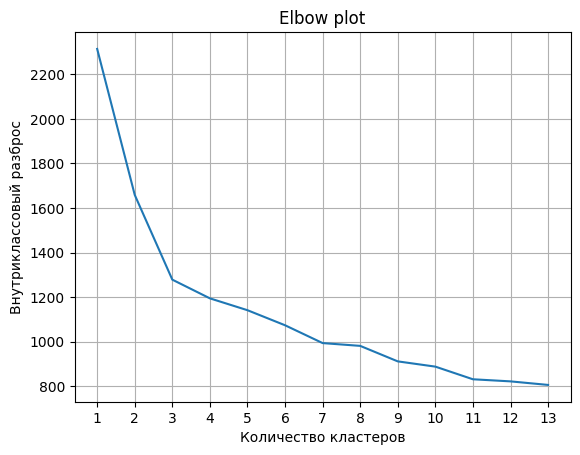

In [10]:
inertia = []
num_of_clusters = np.arange(1,14) # наилучшее число клатеров ищем в диапазоне от 1 до 14
for i in num_of_clusters:
    km = KMeans(n_clusters=i, max_iter=100, random_state=100)
    km.fit(dff)    
    inertia.append(km.inertia_)
    
plt.plot(num_of_clusters, inertia)
plt.title('Elbow plot')
plt.xlabel('Количество кластеров')
plt.ylabel('Внутриклассовый разброс')
plt.xticks(np.arange(1, 14, 1))
plt.grid(True)
plt.show()

**Вопрос:** Какое количество кластеров можно считать оптимальным?

### 📌📌📌 Задание 3. Кластеризация с помощью KMeans
При выполнении задания пользуйтесь справкой по методу k-means: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

После того, как вы определили оптимальное число кластеров, можно приступать к кластеризации. 

**Для всех вариантов:**
1. Проведите кластеризацию методом k-means и запишите ее результаты в отдельный столбец датасета `df`.
2. Выведите на экран информацию о количестве объектов в каждом кластере.
3. Постройте диаграммы размаха значение указанных в вашем варианте переменных по каждому из полученных кластеров:

    **Вариант 1**: Алкоголь и яблочная кислота

    **Вариант 2**: Магний и общие фенолы

    **Вариант 3**: Флавоноиды и оттенок

    **Вариант 4**: Проантоцианы и пролин

    Оба ли признака являются значимыми для кластеризации?

4. **Только для варианта 4**: вина представленные в датасете изготовлены тремя различными производителями (номера производителей - это метки классов в `data.target`)
Если разбить вина на 3 кластера, то не получится ли при этом, что мы кластеризуем по производителям? Исследуйте, насколько кластеры будут совпадать с классами. При этом нужно иметь в виду, что нумерации кластеров и классов могуть не совпадать, поэтому испробуйте все возможные способы перенумеровать кластеры.

Проинтерпретируйте полученные результаты.

Количество объектов в кластерах:
cluster
0    66
1    61
2    51
Name: count, dtype: int64

Анализ значимости признаков для кластеризации:


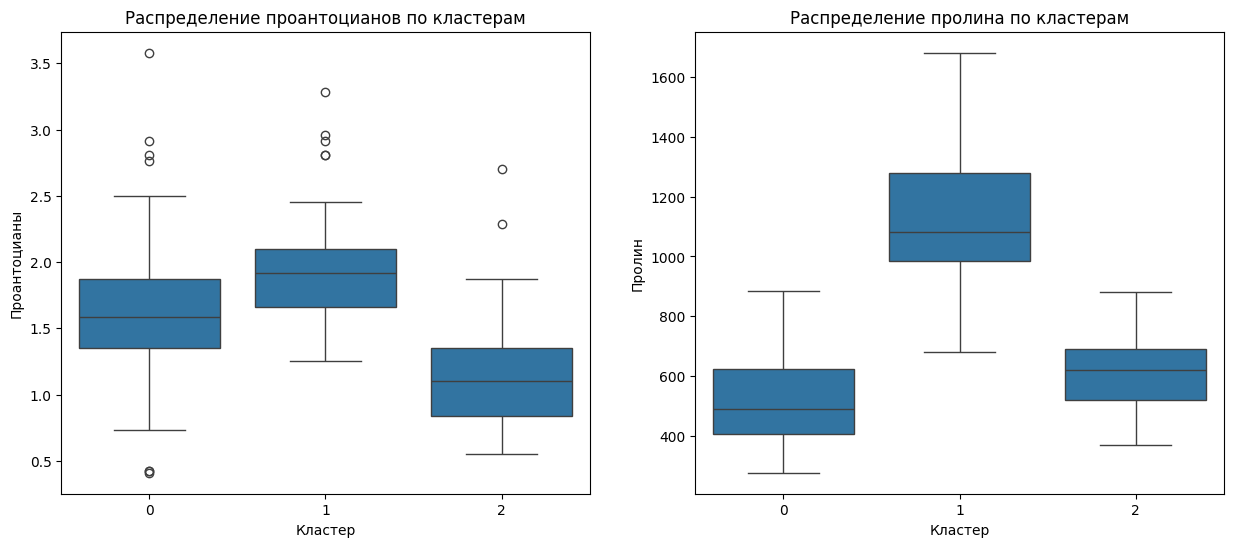


 [[ 0 59  0]
 [66  2  3]
 [ 0  0 48]]

Матрица ошибок (после перестановки меток):
[[59  0  0]
 [ 2 66  3]
 [ 0  0 48]]

Отчет по классификации:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        59
           1       1.00      0.93      0.96        71
           2       0.94      1.00      0.97        48

    accuracy                           0.97       178
   macro avg       0.97      0.98      0.97       178
weighted avg       0.97      0.97      0.97       178



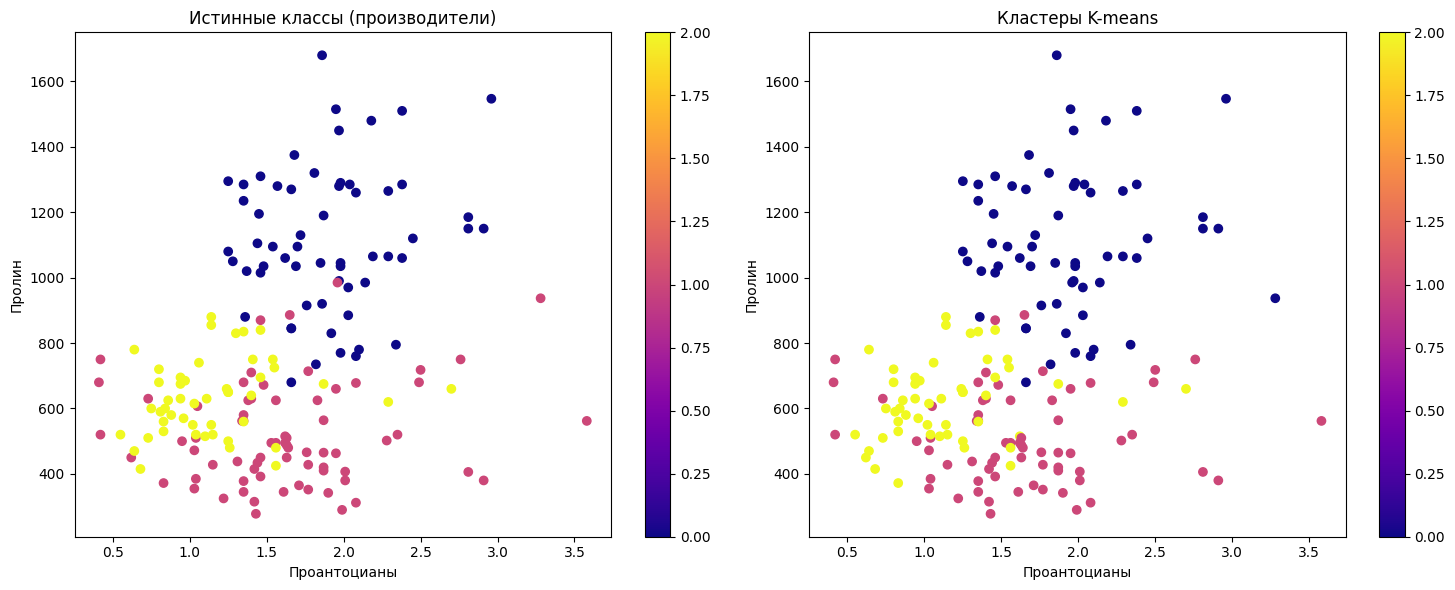


 accuracy совпадения кластеров с истинными классами: 0.972
Средние по скорректированным кластерам:
                  proanthocyanins      proline
adjusted_cluster                              
0                        1.922951  1110.639344
1                        1.627879   509.484848
2                        1.145882   619.058824

Средние по истинным классам:
            proanthocyanins      proline
true_class                              
0                  1.899322  1115.711864
1                  1.630282   519.507042
2                  1.153542   629.895833


In [11]:
## Ваш код
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

optimal_clusters = 3

kmeans = KMeans(n_clusters=optimal_clusters, random_state=100)
cluster_labels = kmeans.fit_predict(dff)

df['cluster'] = cluster_labels
dff['cluster'] = cluster_labels

print("Количество объектов в кластерах:")
print(df['cluster'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
print("\nАнализ значимости признаков для кластеризации:")

sns.boxplot(data=df, x='cluster', y='proanthocyanins', ax=axes[0])
axes[0].set_title('Распределение проантоцианов по кластерам')
axes[0].set_xlabel('Кластер')
axes[0].set_ylabel('Проантоцианы')

sns.boxplot(data=df, x='cluster', y='proline', ax=axes[1])
axes[1].set_title('Распределение пролина по кластерам')
axes[1].set_xlabel('Кластер')
axes[1].set_ylabel('Пролин')

plt.show()

true_labels = data.target
df['true_class'] = true_labels


def match_clusters_to_classes(cluster_labels, true_labels):
    
    cm = confusion_matrix(true_labels, cluster_labels)
    print("\n",cm)
    new_labels = np.zeros_like(cluster_labels)
    for cluster_id in range(cm.shape[1]): 
        indices = np.where(cluster_labels == cluster_id)[0]
        if np.sum(cm[:, cluster_id]) > 0: 
            predicted_class = np.argmax(cm[:, cluster_id])
            new_labels[indices] = predicted_class
    
    return new_labels

adjusted_cluster_labels = match_clusters_to_classes(cluster_labels, true_labels)
#adjusted_cluster_labels = cluster_labels
df['adjusted_cluster'] = adjusted_cluster_labels

print("\nМатрица ошибок (после перестановки меток):")
print(confusion_matrix(true_labels, adjusted_cluster_labels))

print("\nОтчет по классификации:")
print(classification_report(true_labels, adjusted_cluster_labels))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

scatter1 = axes[0].scatter(df['proanthocyanins'], df['proline'], c=df['true_class'], cmap='plasma')
axes[0].set_title('Истинные классы (производители)')
axes[0].set_xlabel('Проантоцианы')
axes[0].set_ylabel('Пролин')
plt.colorbar(scatter1, ax=axes[0])

scatter2 = axes[1].scatter(df['proanthocyanins'], df['proline'], c=df['adjusted_cluster'], cmap='plasma')
axes[1].set_title('Кластеры K-means')
axes[1].set_xlabel('Проантоцианы')
axes[1].set_ylabel('Пролин')
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()

accuracy = np.sum(adjusted_cluster_labels == true_labels) / len(true_labels)
print(f"\n accuracy совпадения кластеров с истинными классами: {accuracy:.3f}")

cluster_means = df.groupby('adjusted_cluster').mean()
true_class_means = df.groupby('true_class').mean()

print("Средние по скорректированным кластерам:")
print(cluster_means[['proanthocyanins', 'proline']])
print("\nСредние по истинным классам:")
print(true_class_means[['proanthocyanins', 'proline']])